# <center> Rain prediction </center>

## Recurrent Nural Net Approach

In [1]:
## importing basic modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#try:
#    !pip install tensorflow-gpu
#except:
#!pip install tensorflow
import tensorflow as tf

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (20,20)


# importing dataset

In [2]:

dataset = pd.read_csv('Temp_and_rain.csv')

In [3]:
dataset.head()

,tem,Month,Year,rain
0,16.9760,1,1901,18.5356
1,19.9026,2,1901,16.2548
2,24.3158,3,1901,70.7981
3,28.1834,4,1901,66.1616
4,27.8892,5,1901,267.2150


## checking missing data

## No missing value

In [4]:
dataset.isnull().sum()

tem      0
Month    0
Year     0
rain     0
dtype: int64

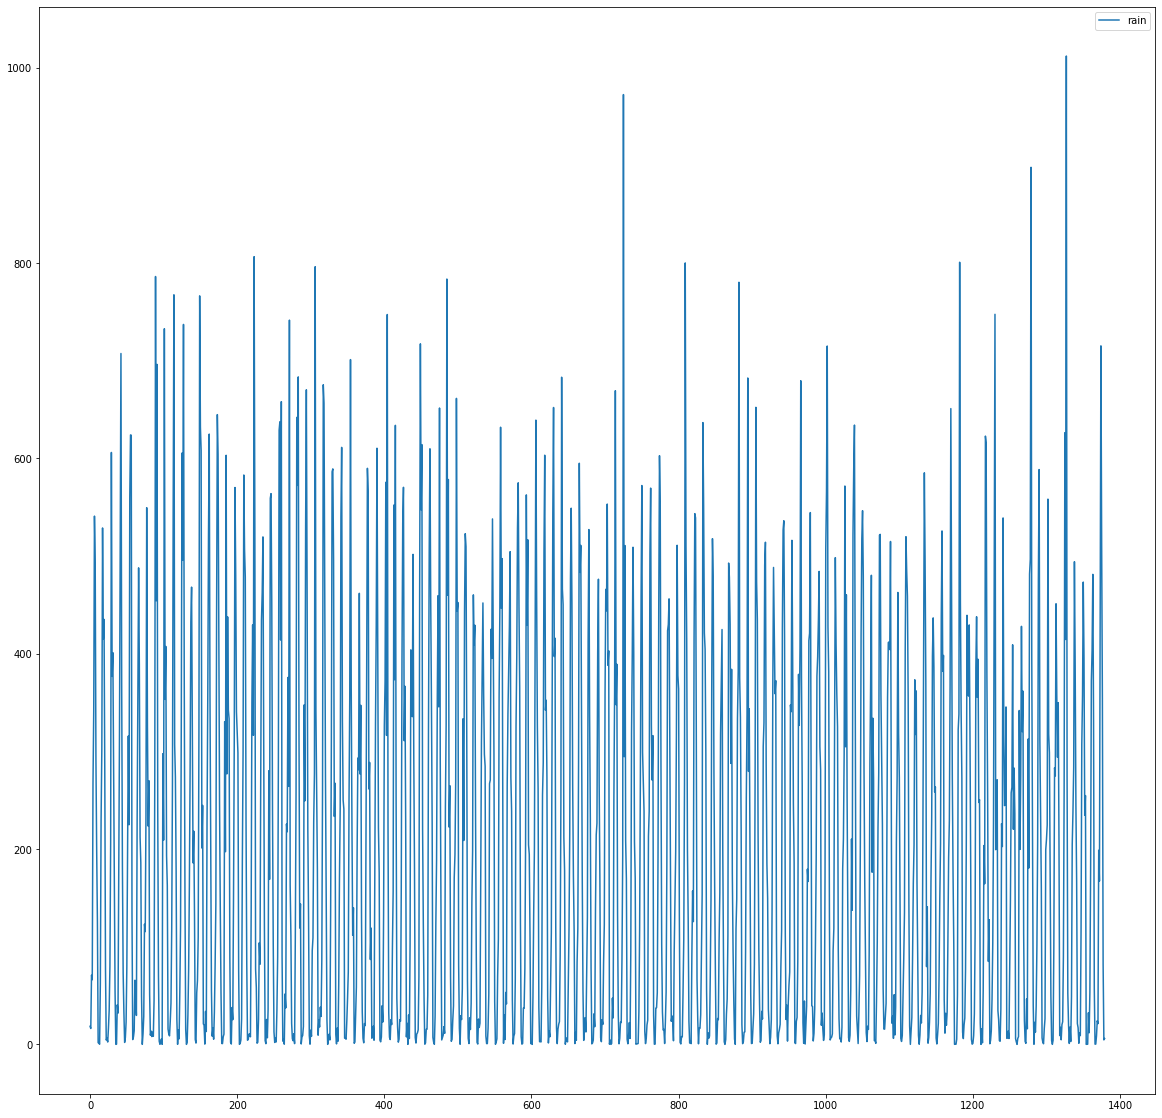

In [5]:
dataset[['rain']].plot()

## histogram of the rain 

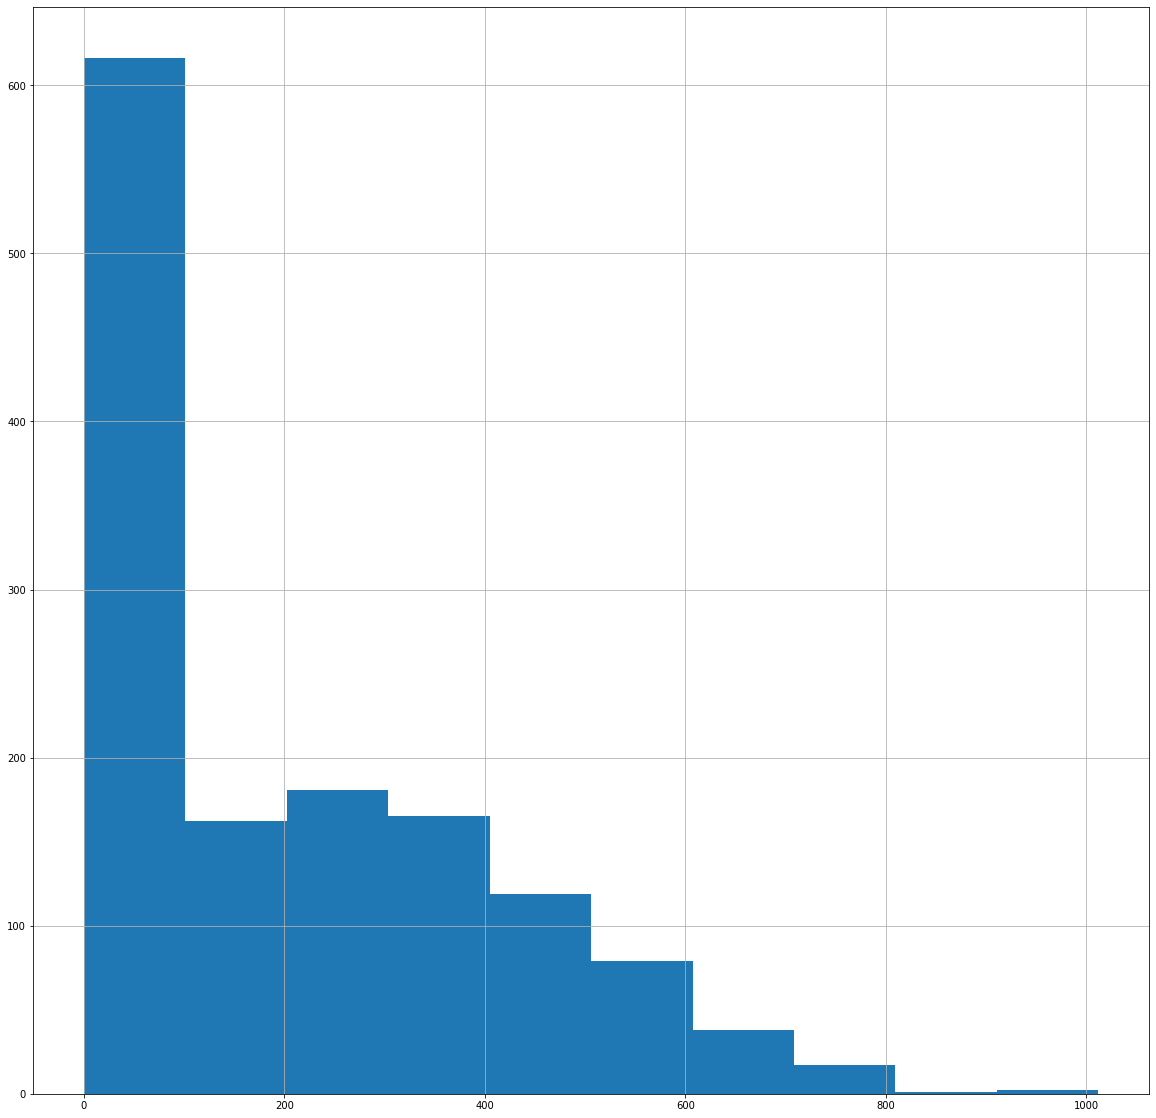

In [6]:
dataset.rain.hist()

## histogram of the temp

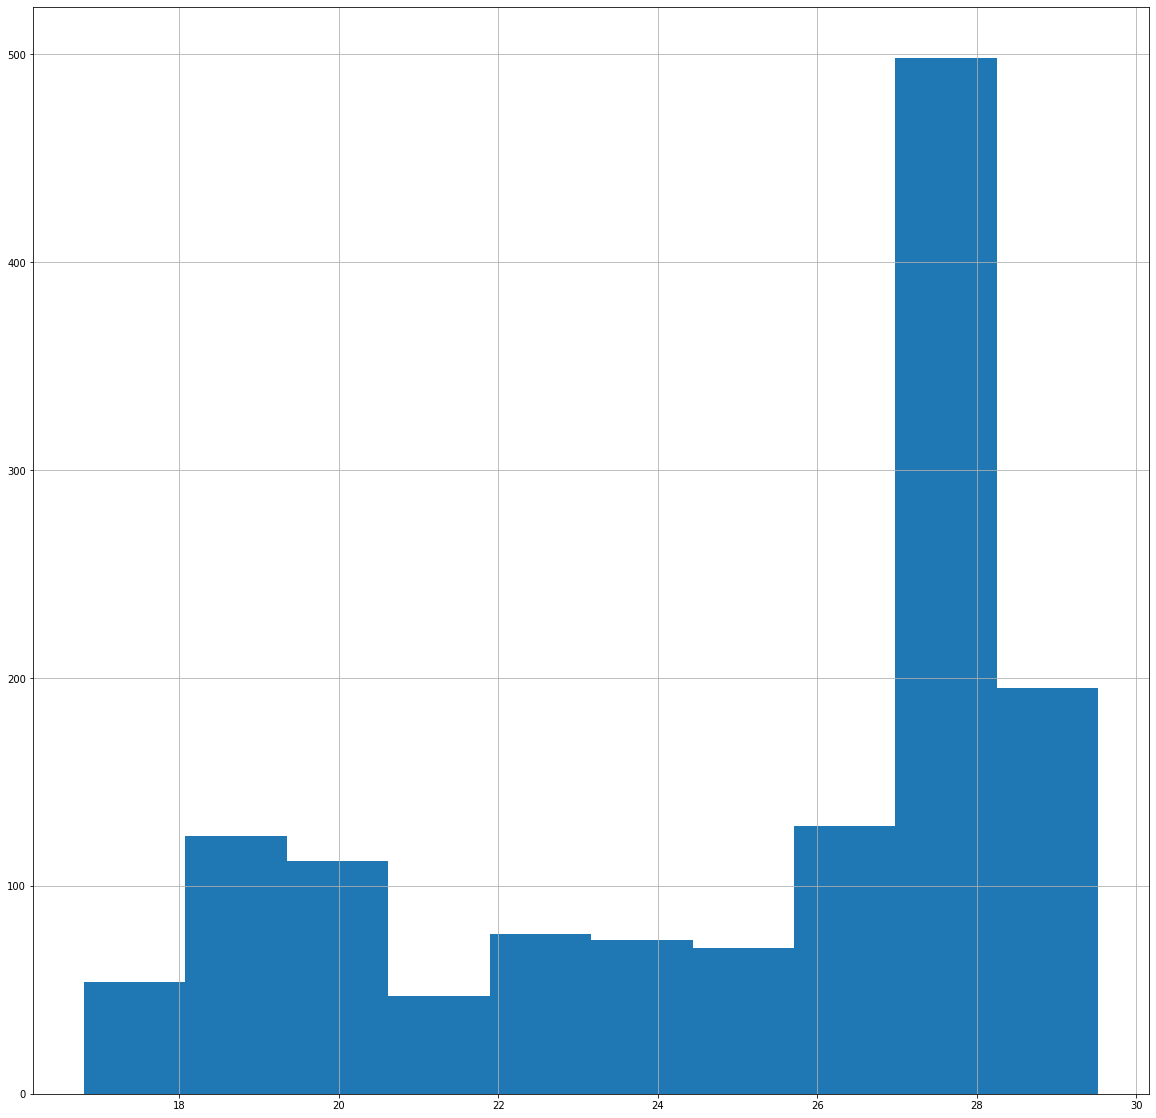

In [7]:
dataset.tem.hist()

## Rain in different year

No handles with labels found to put in legend.


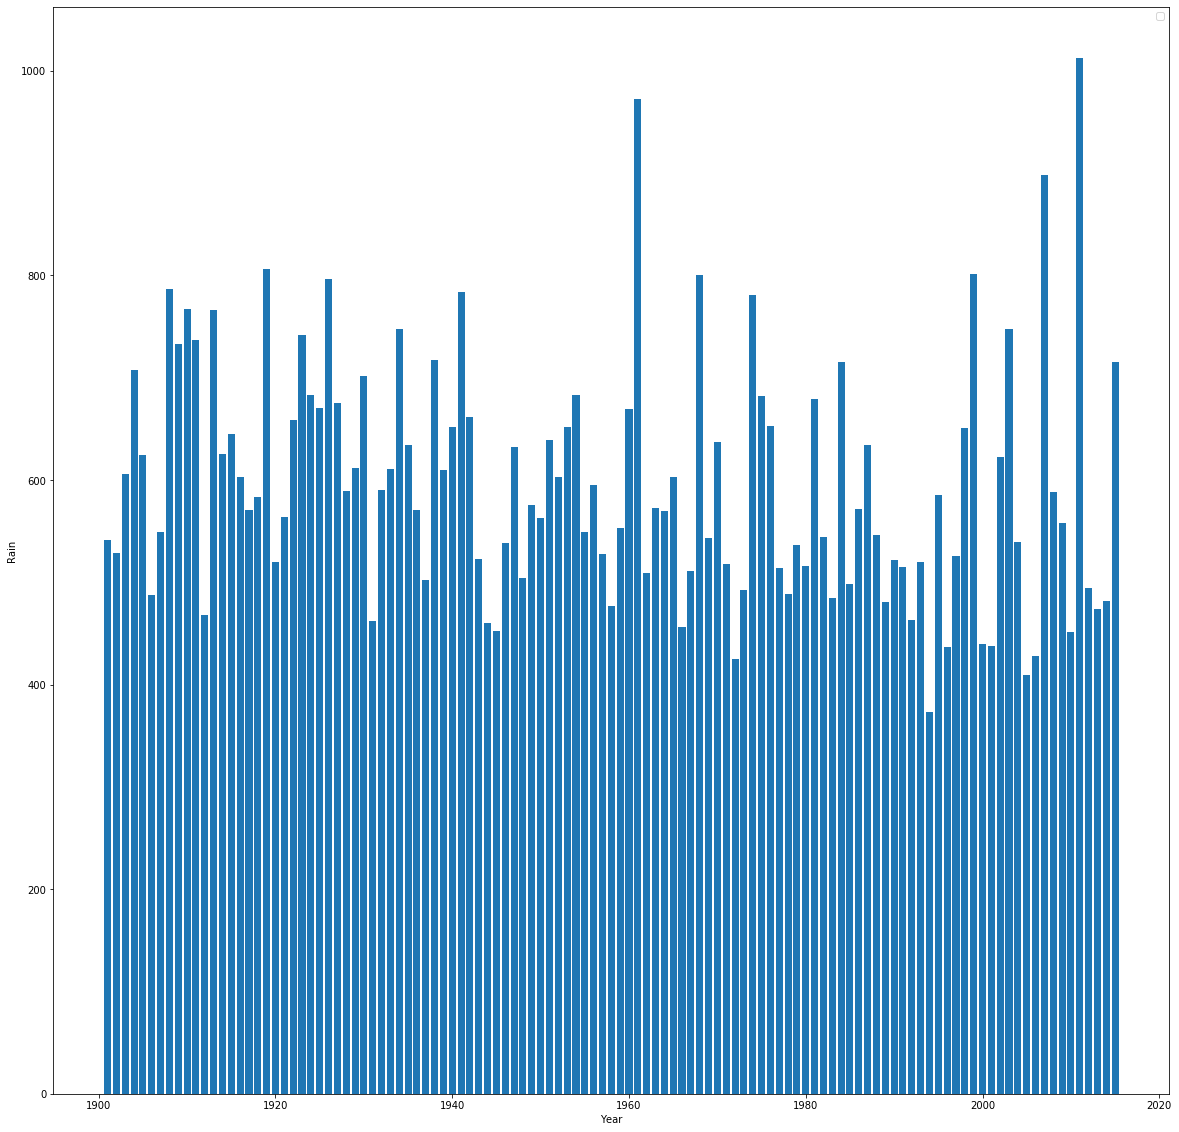

In [8]:
plt.bar(dataset['Year'],dataset['rain'])
plt.xlabel("Year")
plt.ylabel("Rain")
plt.legend()

## Temp to Rain plot

No handles with labels found to put in legend.


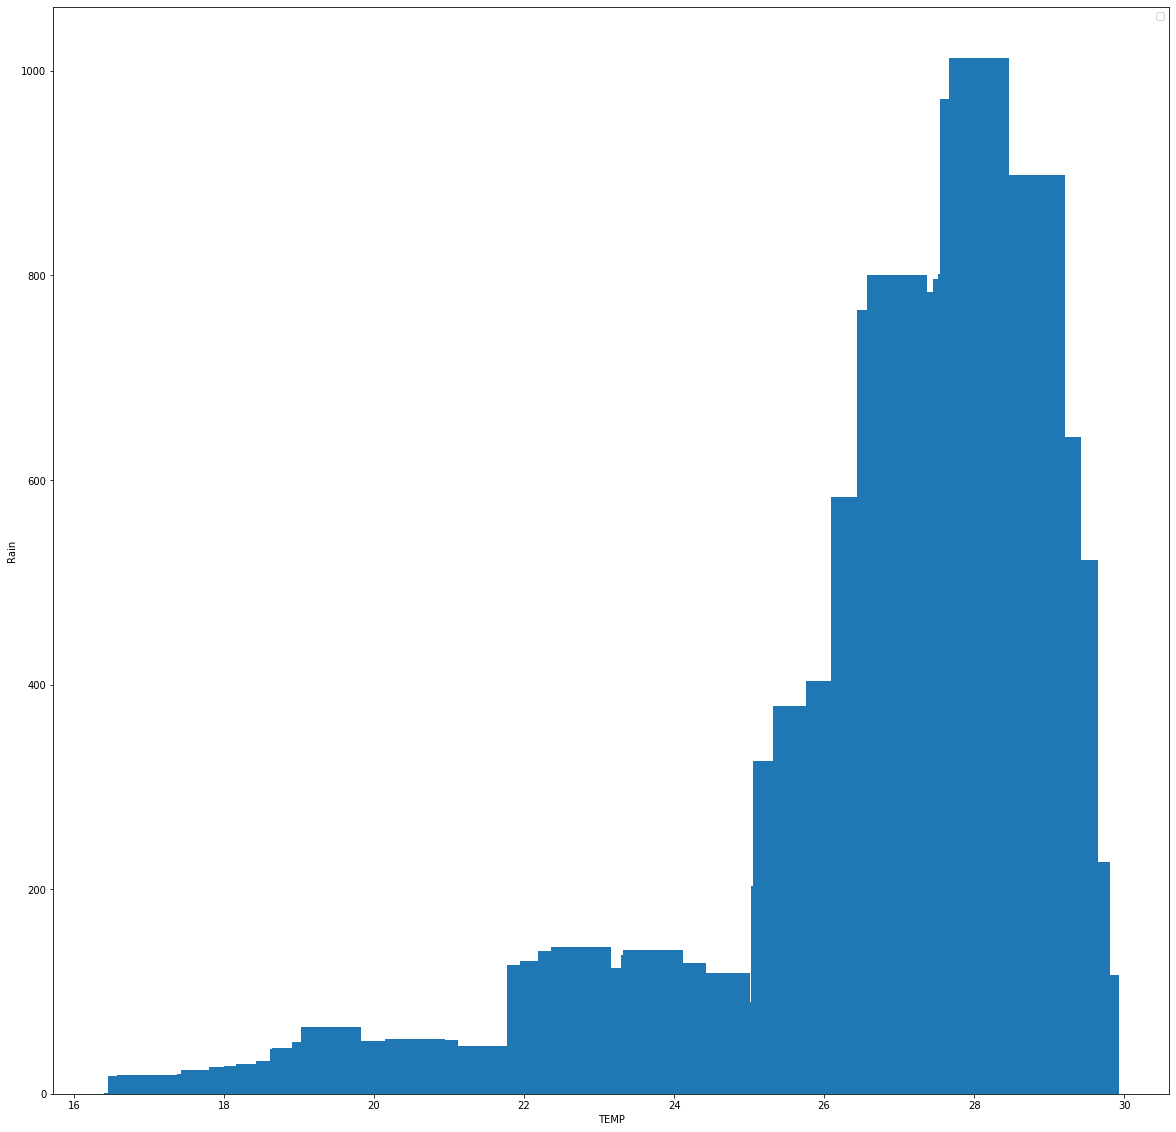

In [9]:
plt.bar(dataset['tem'],dataset['rain'])
plt.xlabel("TEMP")
plt.ylabel("Rain")
plt.legend()

In [10]:
import seaborn as sns

In [11]:
correlation = dataset.corr()

## Correlation matrix

In [12]:
correlation

,tem,Month,Year,rain
tem,1.000000,1.598089e-01,5.168564e-02,0.699846
Month,0.159809,1.000000e+00,-3.953899e-17,0.135204
Year,0.051686,-3.953899e-17,1.000000e+00,-0.027024
rain,0.699846,1.352039e-01,-2.702355e-02,1.000000


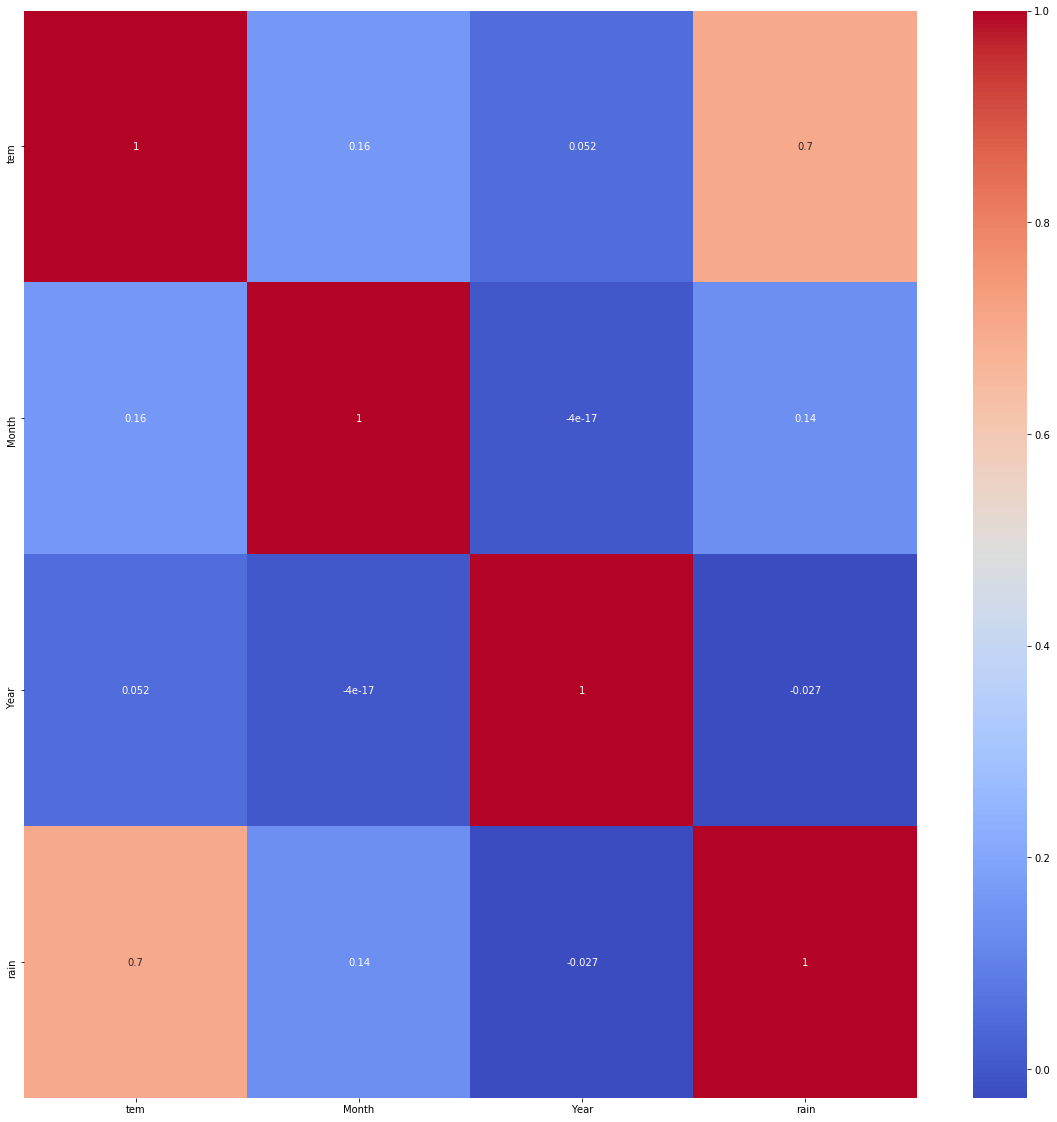

In [13]:
sns.heatmap(correlation,cmap='coolwarm',annot=True)

In [14]:
## setting the style first
sns.set(style="whitegrid",color_codes=True) ## change style

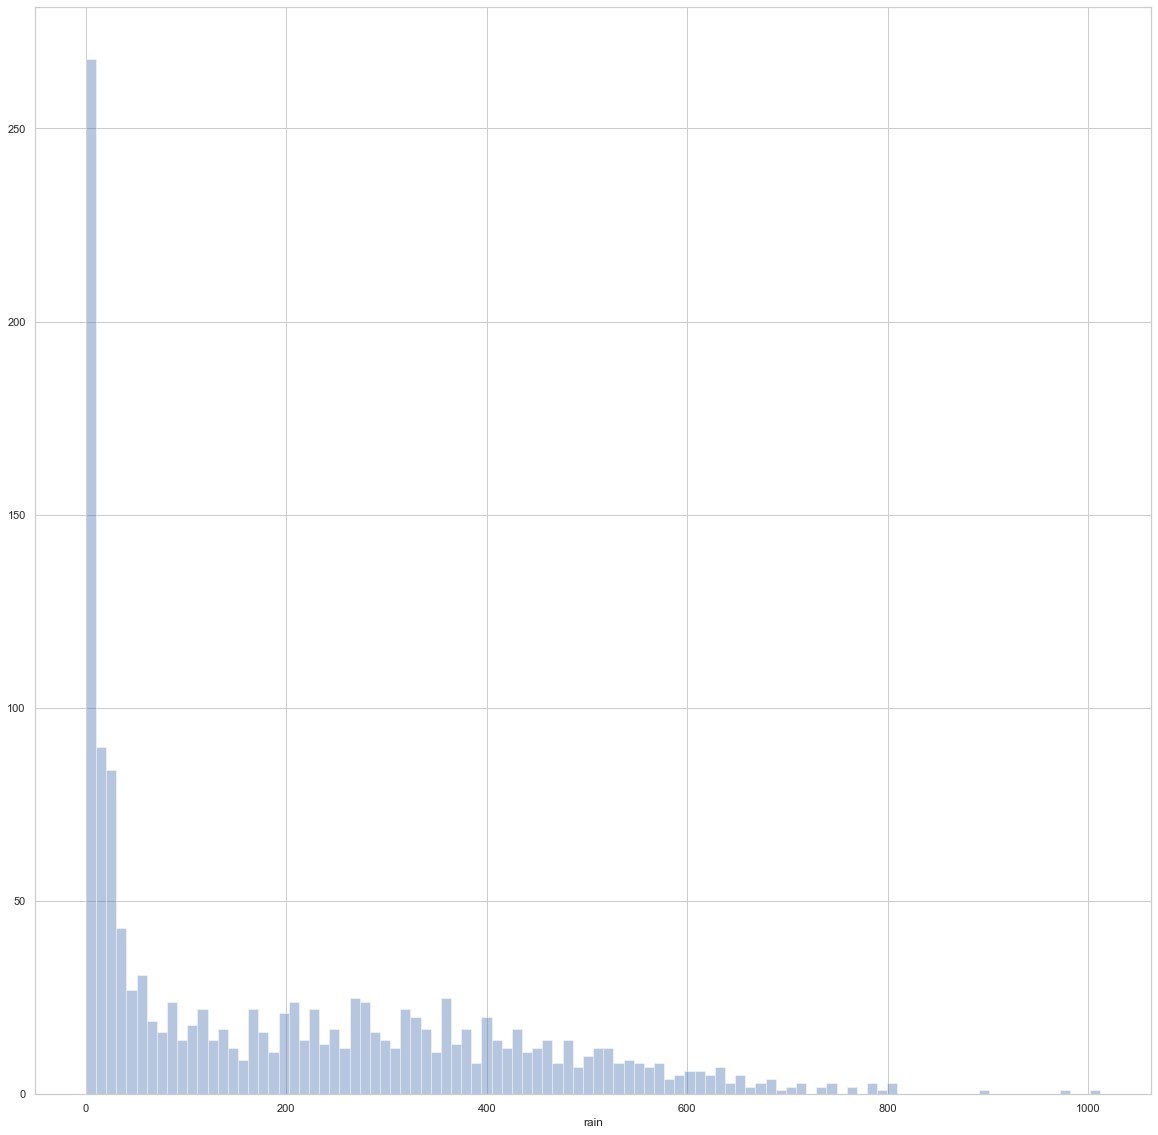

In [15]:
sns.distplot(dataset['rain'], kde=False, bins=100);

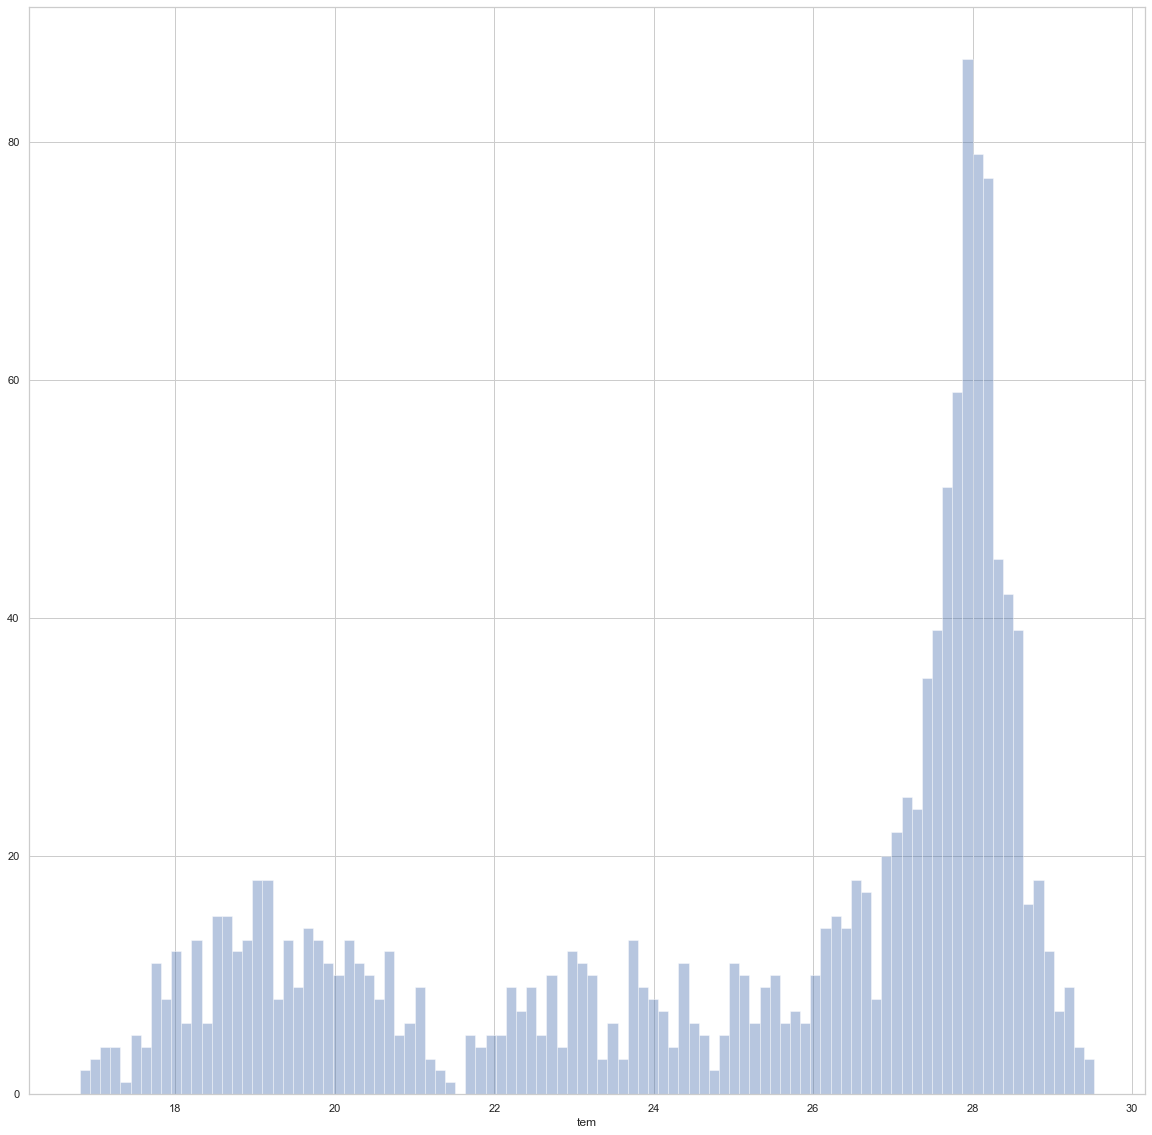

In [16]:
sns.distplot(dataset['tem'],kde=False, bins=100);


## relational scatter plot of differnt rain quantity in different Year

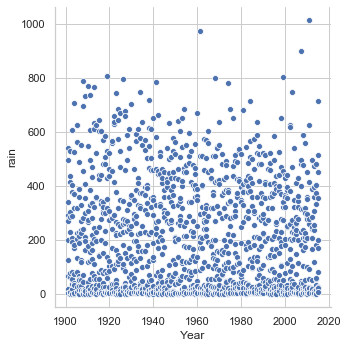

In [17]:
sns.relplot(x="Year", y="rain", data=dataset);

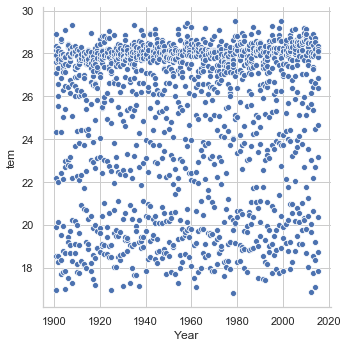

In [18]:
sns.relplot(x="Year", y="tem", data=dataset);

## relation betwen temp and rain in different year

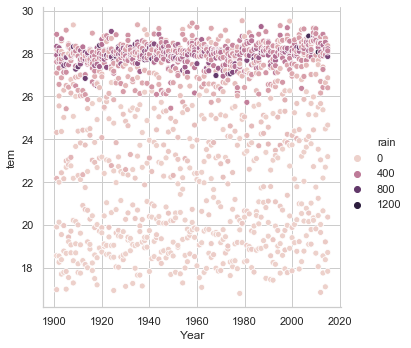

In [19]:
sns.relplot(x="Year", y="tem", hue="rain", data=dataset);

## box plot

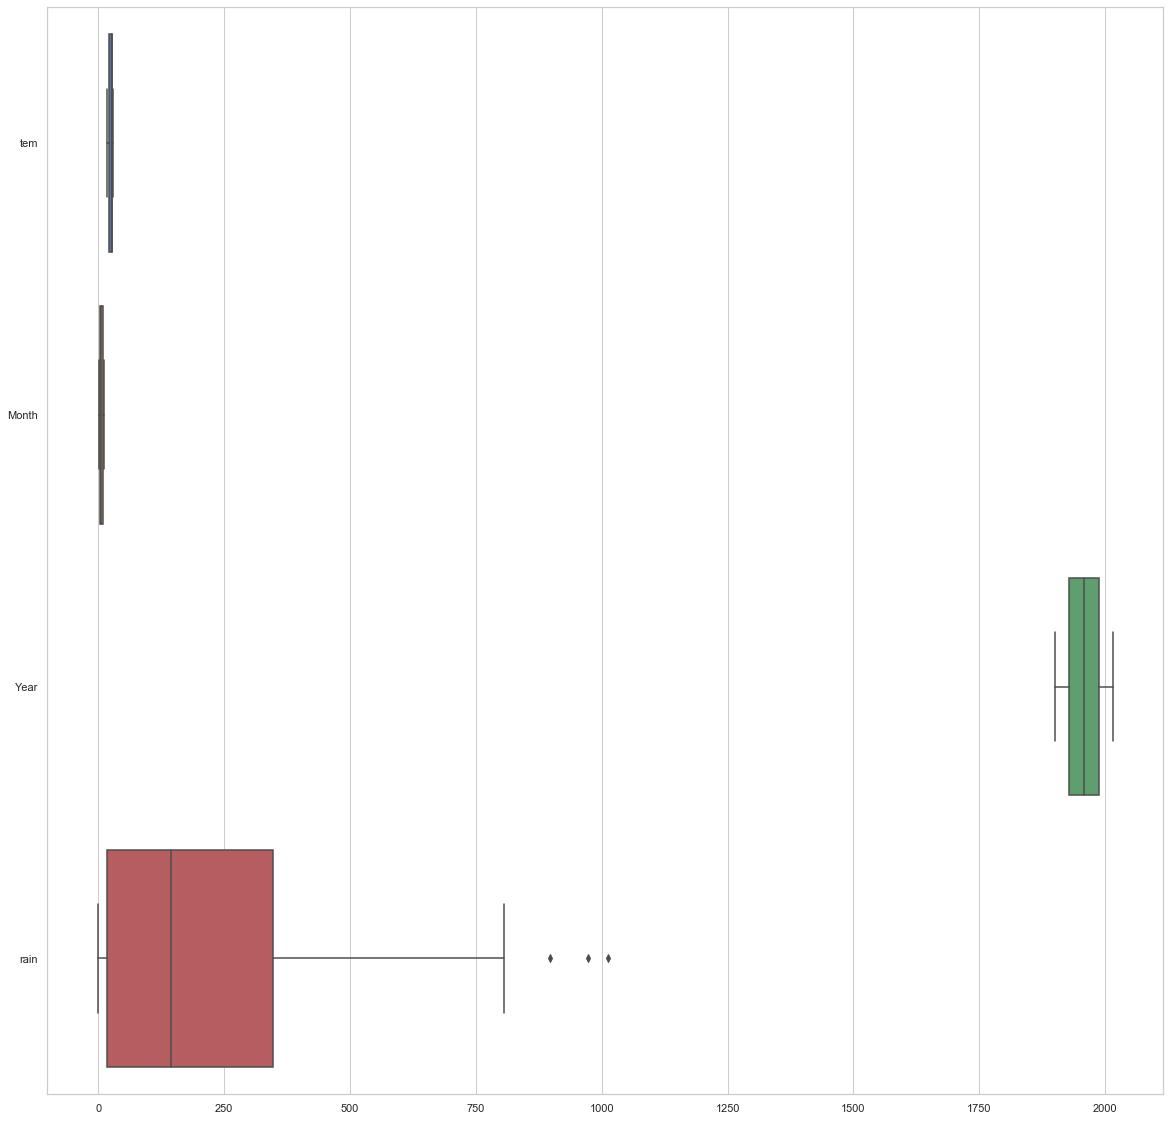

In [20]:
sns.boxplot(data=dataset,orient='h')

# model selection with preprocessing

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

## splitting the feature matrix and target

In [22]:
dataset.head()
X = dataset.drop('rain',axis=1)
X = X.drop('tem',axis=1)
y = dataset[['rain','tem']]

In [23]:
X.head()

,Month,Year
0,1,1901
1,2,1901
2,3,1901
3,4,1901
4,5,1901


In [24]:
y.head()

,rain,tem
0,18.5356,16.9760
1,16.2548,19.9026
2,70.7981,24.3158
3,66.1616,28.1834
4,267.2150,27.8892


###  to use RNN you have to maintain the value between a limit hence transforming it

# we transform the y so after predict we have to inverse transeform it

In [25]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=.2)


## importing RNN module

In [26]:
from keras import Sequential
from keras.layers import Dense,Dropout,LSTM,Flatten

In [27]:
print (x_train.shape)
print (x_test.shape)

(1104, 2)
(276, 2)


In [28]:
x_train = np.array(x_train)
x_test = np.array(x_test)



In [29]:
x_train

array([[   3, 1991],
       [   7, 1986],
       [  12, 1921],
       ...,
       [   7, 1940],
       [   2, 1958],
       [  10, 1977]], dtype=int64)

## this reshaping is very important before feeding to RNN

In [30]:
print (x_train.shape)
print (x_test.shape)
print (y_train.shape)
print (y_test.shape)

(1104, 2)
(276, 2)
(1104, 2)
(276, 2)


In [31]:
n_col = x_train.shape[1]

## CREATE A BASIC RNN MODEL

In [32]:
from keras.utils import plot_model
from keras.models import Model
from keras.layers import Input
from keras.layers import Dense
visible = Input(shape=(n_col,))
hidden1 = Dense(100, activation='relu')(visible)
hidden2 = Dense(200, activation='relu')(hidden1)
hidden3 = Dense(100, activation='relu')(hidden2)
hidden4 = Dense(100, activation='relu')(hidden3)
hidden5 = Dense(100, activation='relu')(hidden4)
hidden6 = Dense(100, activation='relu')(hidden5)
hidden7 = Dense(100, activation='relu')(hidden6)
output = Dense(2)(hidden7)
model = Model(inputs=visible, outputs=output)
model.compile(optimizer='adam',loss='mean_absolute_error')

ImportError: cannot import name 'plot_model' from 'keras.utils' (C:\Users\Thoufiq\anaconda3\lib\site-packages\keras\utils\__init__.py)

In [33]:
model.fit(x_train,y_train,epochs = 100)

NameError: name 'model' is not defined

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

In [ ]:
model.evaluate(x_test,y_test)

## KNN APPROACH

In [34]:
dataset = pd.read_csv('Temp_and_rain.csv')
X = dataset.drop('rain',axis=1)
X = X.drop('tem',axis=1)
y = dataset[['rain','tem']]
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=.2)

In [35]:
from sklearn.neighbors import KNeighborsRegressor

In [36]:
knn = KNeighborsRegressor(n_neighbors=5)

In [37]:
knn.fit(x_train,y_train)
predicted=knn.predict(x_test)

In [38]:
predicted

array([[  6.125786,  20.36272 ],
       [ 11.99398 ,  20.23726 ],
       [352.2952  ,  28.18572 ],
       [249.8356  ,  27.42066 ],
       [ 52.911606,  24.39658 ],
       [ 28.997878,  22.1045  ],
       [146.08906 ,  26.61346 ],
       [194.56346 ,  27.70916 ],
       [ 19.92355 ,  20.07918 ],
       [345.4024  ,  28.36146 ],
       [605.1064  ,  28.0256  ],
       [262.1018  ,  28.174   ],
       [492.347   ,  27.73234 ],
       [371.96    ,  28.18162 ],
       [459.3372  ,  27.82096 ],
       [314.8088  ,  27.85506 ],
       [365.1838  ,  27.7293  ],
       [197.772824,  25.7869  ],
       [ 79.126318,  22.15924 ],
       [ 27.171356,  21.9983  ],
       [ 24.582376,  22.38462 ],
       [ 15.319006,  19.71946 ],
       [ 12.306936,  19.14384 ],
       [ 84.400872,  23.84792 ],
       [408.802   ,  27.58648 ],
       [449.1852  ,  28.0083  ],
       [204.0774  ,  25.49714 ],
       [167.07295 ,  26.61626 ],
       [  5.109576,  18.60094 ],
       [427.9664  ,  28.1309  ],
       [ 8

In [39]:
model.evaluate(x_test,y_test)

NameError: name 'model' is not defined

In [40]:
accuracy=[]
for k in range(1,50):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(x_train,y_train)
    accuracy.append(knn.score(x_test,y_test))


    

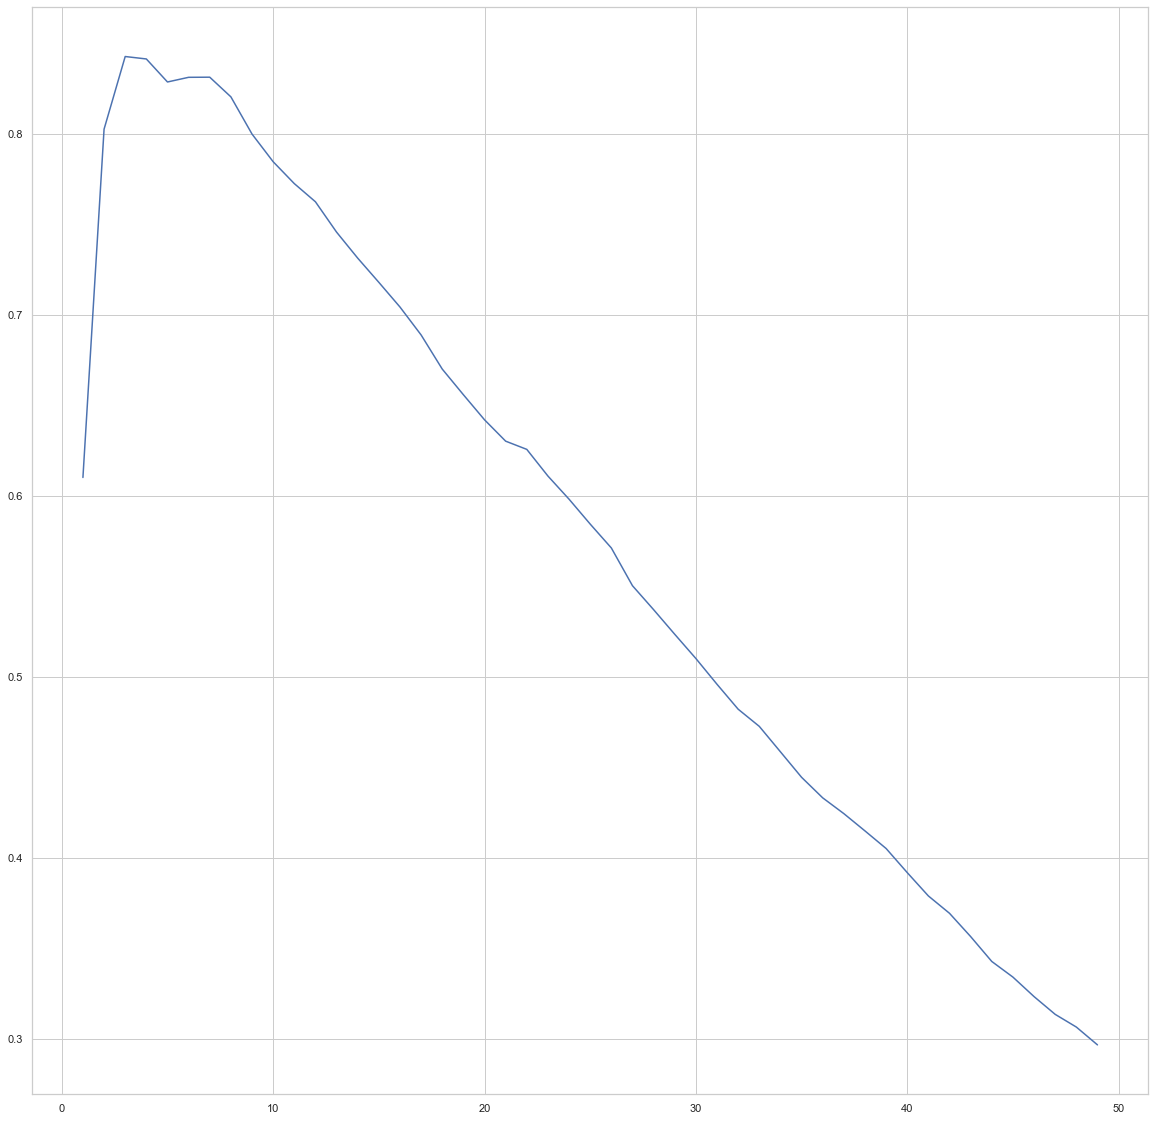

In [41]:
plt.plot(range(1,50),accuracy)

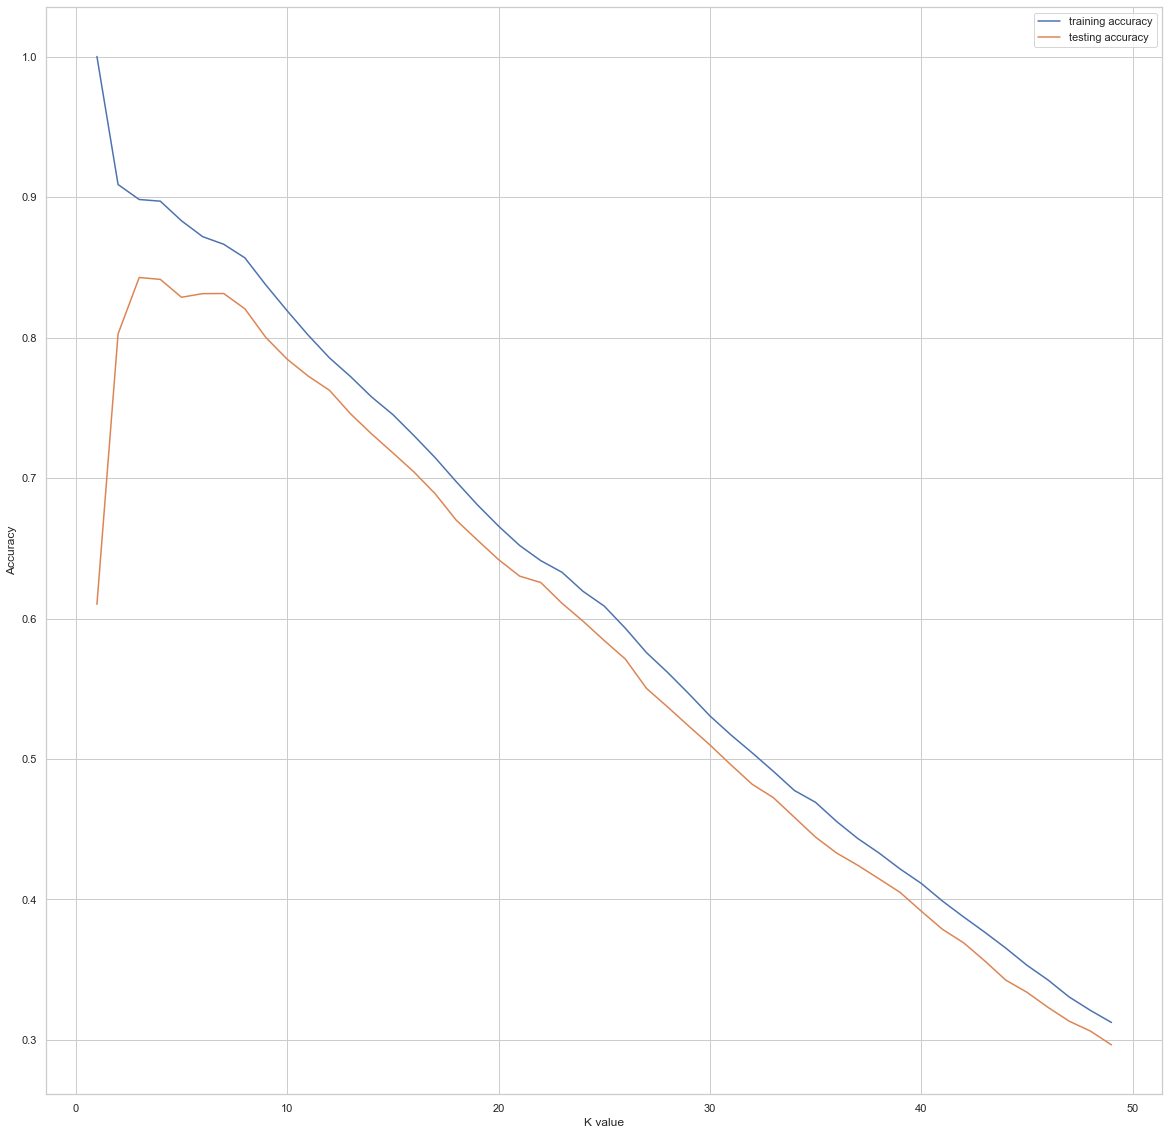

In [42]:
training_accuracy=[]
testing_accuracy=[]

neighbors = list(range(1,50))


for k in neighbors:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(x_train,y_train)
    training_accuracy.append(knn.score(x_train,y_train))
    testing_accuracy.append(knn.score(x_test,y_test))    

plt.plot(neighbors,training_accuracy,label='training accuracy')
plt.plot(neighbors,testing_accuracy,label='testing accuracy')
plt.ylabel("Accuracy")
plt.xlabel("K value")
plt.legend()



## CROSS VAL SCORE

In [43]:
from sklearn.model_selection import cross_val_score

knn = KNeighborsRegressor(n_neighbors=5)

scores = cross_val_score(knn,X,y,cv=10)

print (scores)
print (scores.mean())

print ("Mean Accuracy "+str(scores.mean()))




[0.59211455 0.72080578 0.71325205 0.69747974 0.73090347 0.68391808
 0.75914162 0.7310445  0.67399532 0.55350335]
0.6856158454311624
Mean Accuracy 0.6856158454311624


# now we find cross val score for different K value

[0.767219130123575, 0.7504495412914821, 0.7624730560164805, 0.6860212401999797, 0.6856158454311624, 0.6688793824249369, 0.6541048739887201, 0.6259568886812638, 0.5826127493585325, 0.5579892508866422, 0.5368138911824402, 0.52204536786635, 0.49034831303446086, 0.46685503764452, 0.44577884190480005, 0.43449002857288477, 0.41444911516697636, 0.3933367888557549, 0.3720305180515991, 0.35335464858834087, 0.3373574951063787, 0.3268051034344498, 0.310550644683817, 0.29399522006560935, 0.27698999846943595, 0.25885810992176705, 0.2473254767722799, 0.23620890835801314, 0.22388281292317758, 0.20943197425539176, 0.19731423450723734, 0.18642757778494107, 0.17607844497162306, 0.16347240433114418, 0.15501211653032448, 0.14325528630909967, 0.13595623877301716, 0.12960860340731775, 0.12365312284351668, 0.11600210591423535, 0.11190206560402119, 0.1047115913279016, 0.10259531346392321, 0.09707796744925075, 0.09063971321347483, 0.08499869381067511, 0.07623010517453795, 0.06785905948268323, 0.061724037862884

Text(0, 0.5, 'scores')

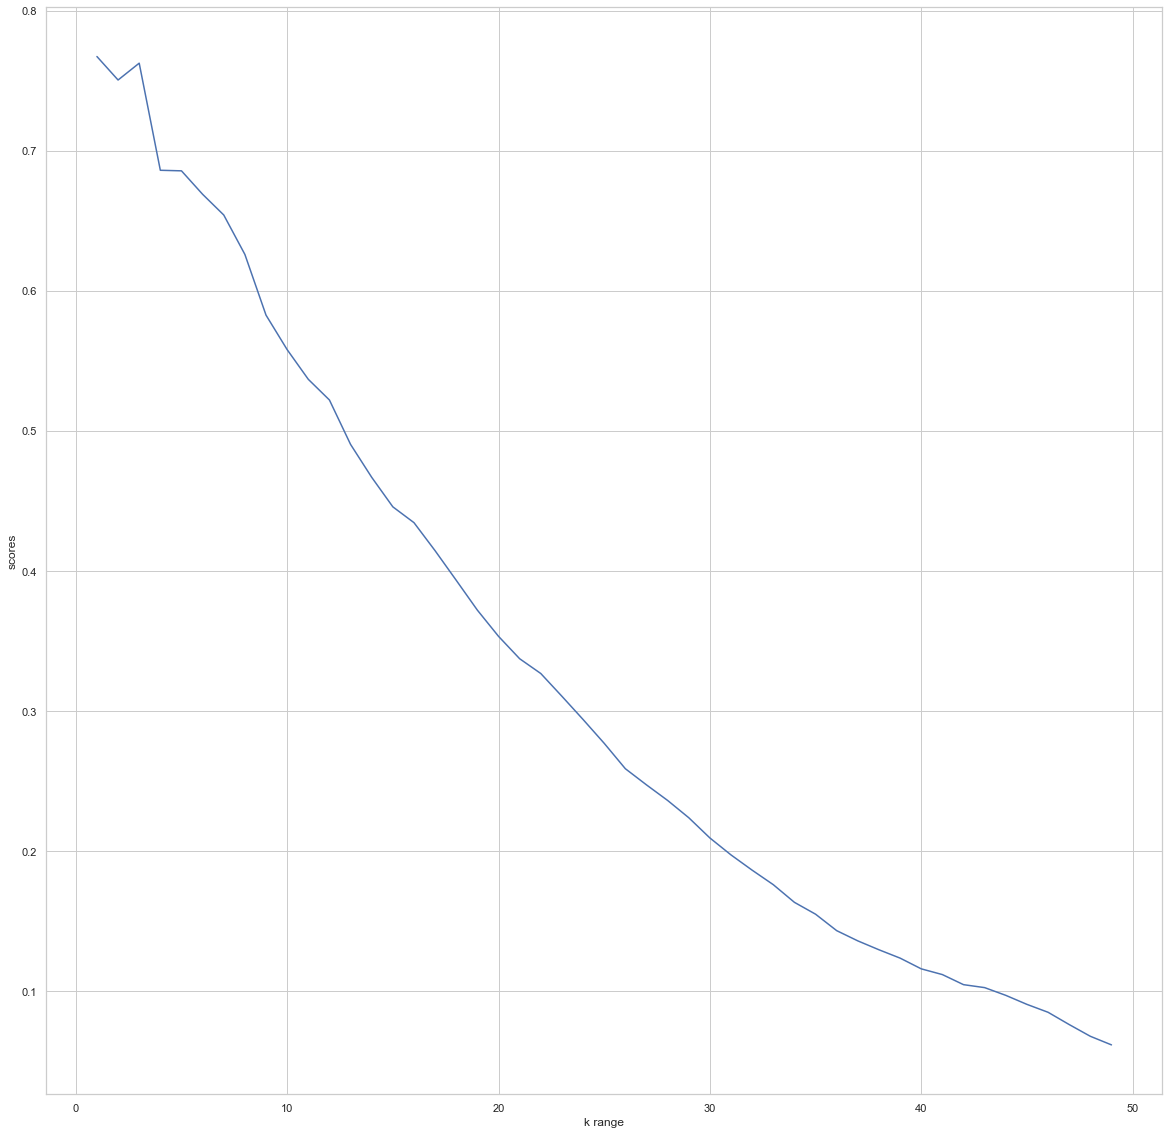

In [44]:



k_range = range(1,50)
k_scores = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn,X,y,cv=10)
    k_scores.append(scores.mean())
    
print (k_scores)


plt.plot(k_range,k_scores)
plt.xlabel("k range")
plt.ylabel("scores")

## Decision Tree Regresson

In [45]:
from sklearn.tree import DecisionTreeRegressor

In [46]:
tree_clf = DecisionTreeRegressor(max_depth=2,random_state=42)

In [47]:
tree_clf.fit(X,y)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [48]:
tree_clf.score(X,y)

0.6829007551927642

## For different Depth

In [49]:
accuracy=[]
for depth in range(1,50):
    dt = DecisionTreeRegressor(max_depth=depth,random_state=42)
    dt.fit(x_train,y_train)
    accuracy.append(dt.score(x_test,y_test))

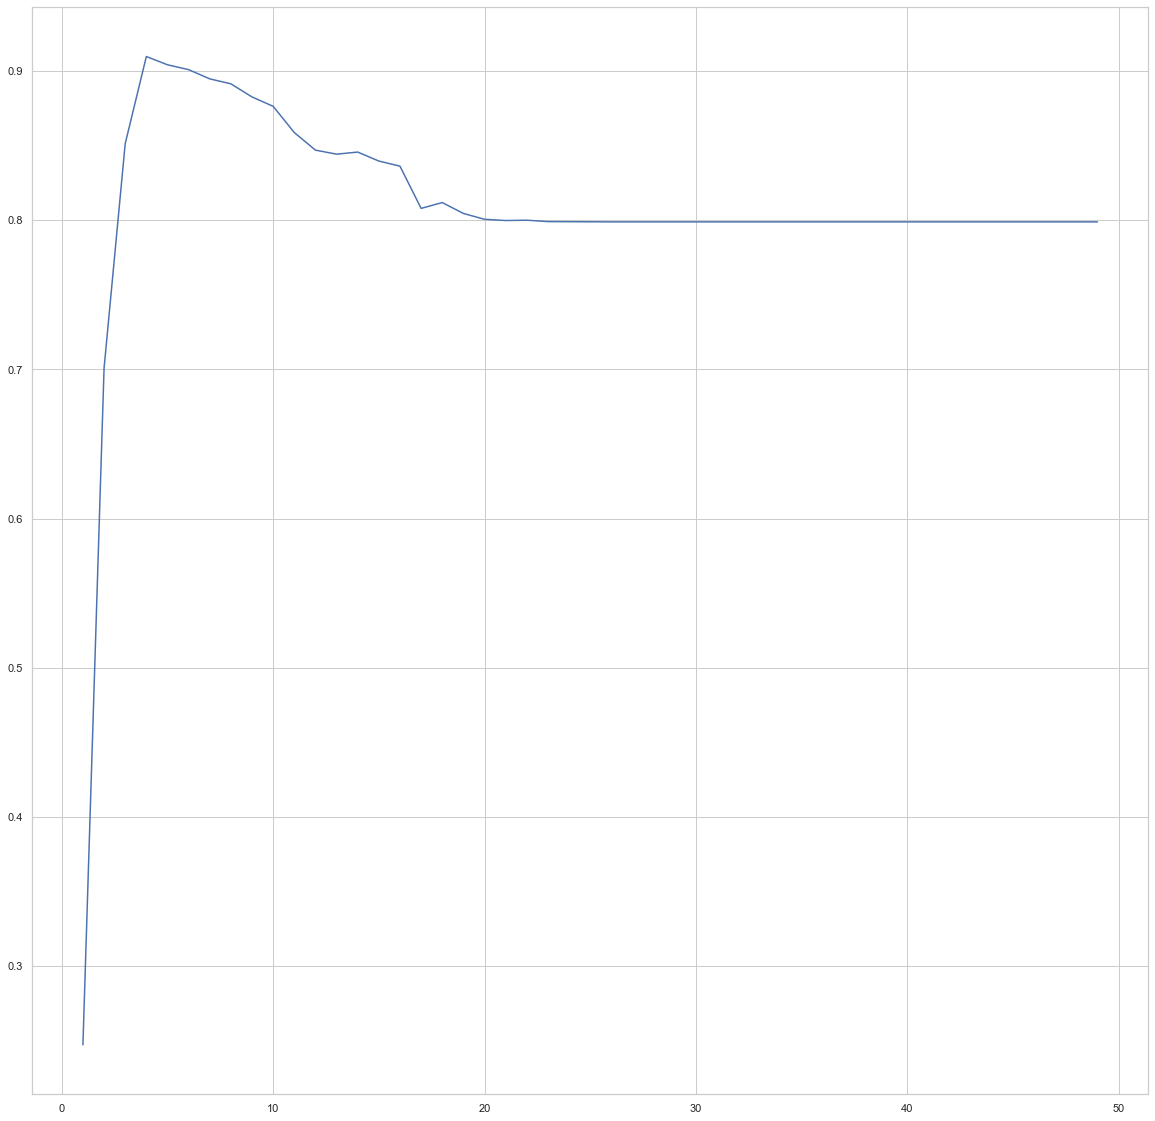

In [50]:
plt.plot(range(1,50),accuracy)

## RANDOM FOREST

In [51]:
from sklearn.ensemble import RandomForestRegressor

In [52]:
rnd = RandomForestRegressor(max_depth=10)

In [53]:
rnd.fit(x_train,y_train)

RandomForestRegressor(max_depth=10)

In [54]:
rnd.score(x_test,y_test)

0.9005204992100687

In [55]:
accuracy=[]
for depth in range(1,50):
    dt = RandomForestRegressor(max_depth=depth,random_state=42)
    dt.fit(x_train,y_train)
    accuracy.append(dt.score(x_test,y_test))

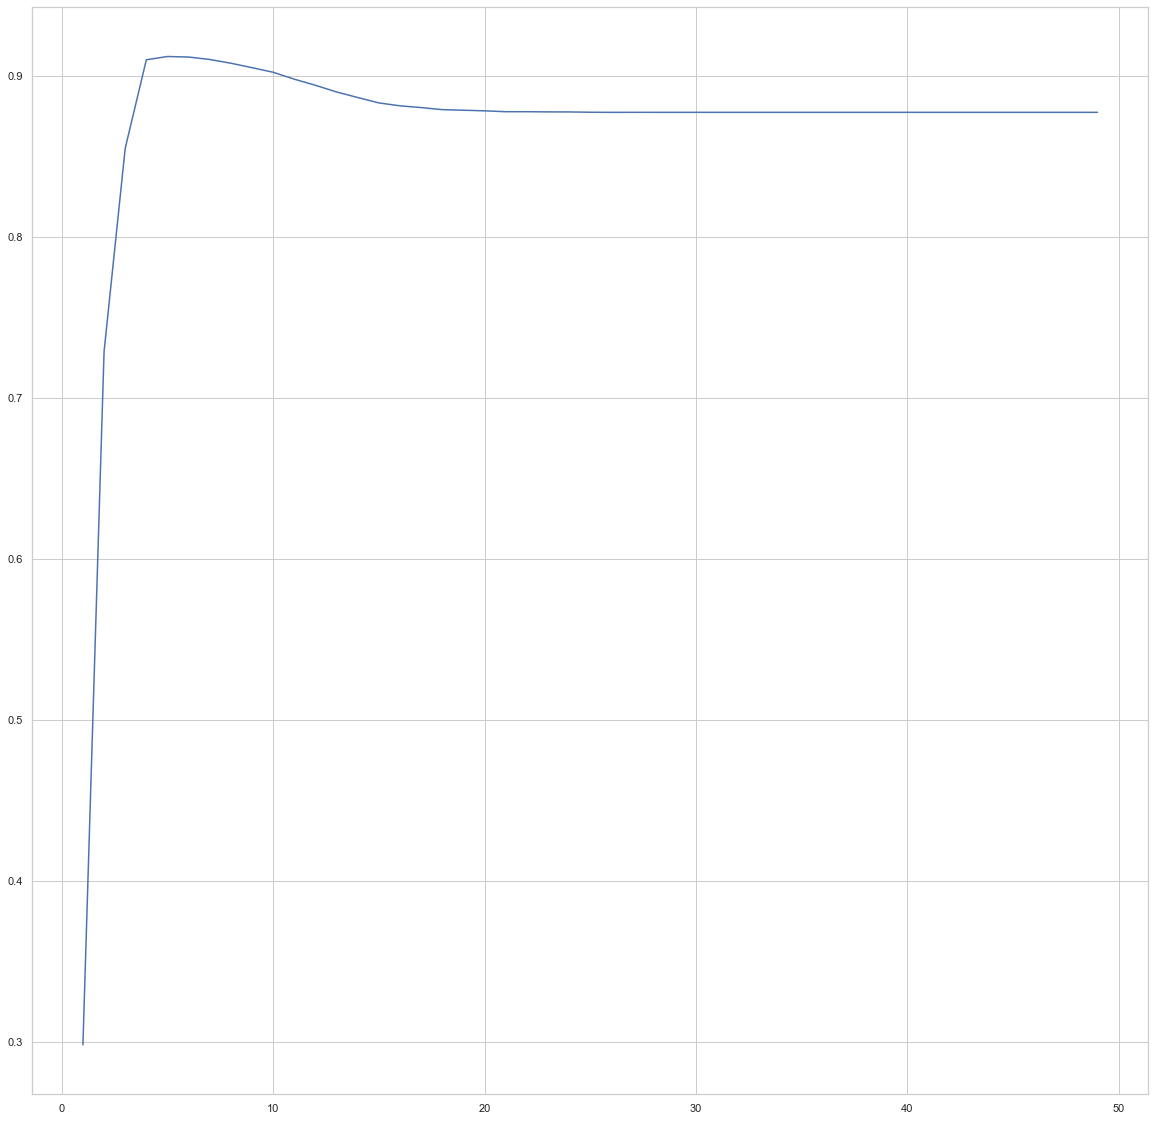

In [56]:
plt.plot(range(1,50),accuracy)

## Combining all the algorithm

![](http://rasbt.github.io/mlxtend/user_guide/regressor/StackingRegressor_files/stackingregression_overview.png)

In [57]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR,LinearSVR
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor

from mlxtend.regressor import StackingRegressor
dtc=DecisionTreeRegressor()
knnc=KNeighborsRegressor()
gbc=GradientBoostingRegressor()
rfc=RandomForestRegressor()



ModuleNotFoundError: No module named 'mlxtend'

In [ ]:
stregr = StackingRegressor(regressors=[dtc,knnc,gbc,rfc], 
                           meta_regressor=knnc)

In [ ]:
y_train

In [ ]:
stregr.fit(x_train, y_train['tem'])

In [ ]:
prediction = stregr.predict(x_test)

In [ ]:
stregr.score(x_test,y_test['tem'])

In [ ]:
stregr.fit(x_train, y_train['rain'])
prediction = stregr.predict(x_test)
stregr.score(x_test,y_test['rain'])